# HFT Feature Training, Runtime Alignment, and Prediction Inspection

This notebook follows `Feature Engineering HFT.md` and the current deployed architecture:

- reconstruct the order book from `snapshot` + `update` messages
- join trades as aggressive flow
- label with executable PnL:
  - `buy_pnl = future_bid - current_ask`
  - `sell_pnl = current_bid - future_ask`
- train both `xgboost` and `lightgbm` regression models on signed `target_exec_return`
- calibrate predicted return magnitude to signed executable return
- save runtime-compatible model artifacts for `inference-python`
- smoke-test prediction through the same live feature path used by `backend-cpp -> inference-python`
- inspect predictions, trading signals, PnL, and feature importance

`target_exec_return` is directional and already executable: positive values mean a long/buy executable edge, negative values mean a short/sell executable edge, and values near zero mean no clear edge after spread/friction. Do not treat it as a future mid-price return and charge spread a second time when estimating expected PnL.

Current system architecture:

`OKX books/trades -> backend-cpp feature builder -> inference-python (LightGBM/XGBoost) -> web-gateway -> frontend`



In [1]:
from pathlib import Path
import csv
import json
import shutil
import sys
import tarfile
import zipfile
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'ml_pipeline').exists():
    REPO_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(REPO_ROOT))

from ml_pipeline.features.common import FEATURE_COLUMNS

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

MODEL_TYPES = ('xgboost', 'lightgbm')
MODEL_LABELS = {
    'xgboost': 'XGBoost',
    'lightgbm': 'LightGBM',
}
print(REPO_ROOT)



/Volumes/Dev/Workspace/okx_trading_platform_sample


## Configuration

Set the archive paths and the research window you want. The notebook validates embedded UTC timestamps before building the dataset. If `AUTO_ALIGN_TO_ARCHIVE_DATES = True`, it will automatically switch to the archive's available date range when the requested book window is not present, while keeping the requested dates visible for auditability.

This notebook also mirrors the current runtime architecture:

- `backend-cpp` computes live feature rows from book `snapshot` + `update` plus recent trades
- `inference-python` loads `pulse_xgboost_v1.joblib` and `pulse_lightgbm_v1.joblib`
- the frontend selects between those two tree models only



In [2]:
BOOKS_ARCHIVE = REPO_ROOT / 'ml_pipeline/train_data/BTC-USDT-L2orderbook-400lv-2026-04-12.tar.gz'
TRADES_ZIP = REPO_ROOT / 'ml_pipeline/train_data/BTC-USDT-trades-2026-04-13.zip'

REQUESTED_BOOKS_START_DAY = '2026-04-06'
REQUESTED_BOOKS_END_DAY = '2026-04-11'
REQUESTED_TRADES_START_DAY = '2026-04-05'
REQUESTED_TRADES_END_DAY = '2026-04-12'

AUTO_ALIGN_TO_ARCHIVE_DATES = True
FORCE_REBUILD_DATASET = False
SAVE_RUNTIME_ALIASES = True
RUN_LIVE_SMOKE_TEST = True

SAMPLE_MS = 1000
HORIZON_MS = 1000
TRADE_LOOKBACK_MS = 1000
EPS = 0.01
SPREAD_EPS_MULTIPLIER = 0.3
NOTIONAL_USD = 5000
RANDOM_STATE = 42
TEST_FRACTION = 0.2
CALIBRATION_FRACTION = 0.2

for path in [BOOKS_ARCHIVE, TRADES_ZIP]:
    print(path, path.exists(), f'{path.stat().st_size / 1024 / 1024:.1f} MB' if path.exists() else '')



/Volumes/Dev/Workspace/okx_trading_platform_sample/ml_pipeline/train_data/BTC-USDT-L2orderbook-400lv-2026-04-12.tar.gz True 143.6 MB
/Volumes/Dev/Workspace/okx_trading_platform_sample/ml_pipeline/train_data/BTC-USDT-trades-2026-04-13.zip True 3.0 MB


## Verify Archive Timestamp Coverage

Archive filenames can differ from timestamps inside the files. This cell reports requested coverage, embedded archive coverage, and the effective dates the rest of the notebook will use. The effective dates are also used to generate dataset, model, prediction, and metrics filenames.



In [3]:
def fmt_ms(ms):
    return datetime.fromtimestamp(ms / 1000, tz=timezone.utc).isoformat() if ms is not None else 'n/a'


def day_range_ms(start_day, end_day):
    start = datetime.fromisoformat(start_day).replace(tzinfo=timezone.utc)
    end = datetime.fromisoformat(end_day).replace(tzinfo=timezone.utc)
    return int(start.timestamp() * 1000), int(end.timestamp() * 1000) + 86_400_000


def archive_day_hint(first_ms, last_ms):
    first = datetime.fromtimestamp(first_ms / 1000, tz=timezone.utc).date().isoformat()
    last = datetime.fromtimestamp(last_ms / 1000, tz=timezone.utc).date().isoformat()
    return first, last


def ranges_overlap(a_start, a_end, b_start, b_end):
    return max(a_start, b_start) < min(a_end, b_end)


def intersect_day_window(req_start_day, req_end_day, arch_start_ms, arch_last_ms):
    req_start_ms, req_end_ms = day_range_ms(req_start_day, req_end_day)
    arch_start_day, arch_end_day = archive_day_hint(arch_start_ms, arch_last_ms)
    arch_start_ms_floor, arch_end_ms_excl = day_range_ms(arch_start_day, arch_end_day)
    if ranges_overlap(req_start_ms, req_end_ms, arch_start_ms, arch_last_ms + 1):
        eff_start_ms = max(req_start_ms, arch_start_ms_floor)
        eff_end_ms = min(req_end_ms, arch_end_ms_excl)
        eff_start_day = datetime.fromtimestamp(eff_start_ms / 1000, tz=timezone.utc).date().isoformat()
        eff_end_day = datetime.fromtimestamp((eff_end_ms - 1) / 1000, tz=timezone.utc).date().isoformat()
        return eff_start_day, eff_end_day, True
    if AUTO_ALIGN_TO_ARCHIVE_DATES:
        return arch_start_day, arch_end_day, False
    return req_start_day, req_end_day, False


def _read_last_json_line(raw):
    last = None
    count = 0
    actions = {}
    for line in raw:
        payload = json.loads(line)
        action = str(payload.get('action', '') or '').lower()
        actions[action] = actions.get(action, 0) + 1
        last = payload
        count += 1
    return last, count, actions


def inspect_books_archive(path):
    with tarfile.open(path, 'r:gz') as tf:
        member = next(m for m in tf.getmembers() if m.isfile())
        raw = tf.extractfile(member)
        if raw is None:
            raise FileNotFoundError(f'Unable to read {member.name}')
        first_payload = json.loads(raw.readline())
        last_payload, tail_count, actions = _read_last_json_line(raw)
        if last_payload is None:
            last_payload = first_payload
        first_action = str(first_payload.get('action', '') or '').lower()
        actions[first_action] = actions.get(first_action, 0) + 1
        return {
            'rows': tail_count + 1,
            'first_ms': int(first_payload.get('ts', 0) or 0),
            'last_ms': int(last_payload.get('ts', 0) or 0),
            'actions': actions,
        }


def inspect_trades_zip(path):
    first = last = None
    count = 0
    with zipfile.ZipFile(path) as zf:
        name = next(n for n in zf.namelist() if not n.endswith('/'))
        with zf.open(name) as raw:
            reader = csv.DictReader((line.decode('utf-8') for line in raw))
            for row in reader:
                ts = int(float(row.get('created_time', '0') or 0))
                if first is None:
                    first = ts
                last = ts
                count += 1
    return {'rows': count, 'first_ms': first, 'last_ms': last}


books_info = inspect_books_archive(BOOKS_ARCHIVE)
trades_info = inspect_trades_zip(TRADES_ZIP)
book_req_start, book_req_end = day_range_ms(REQUESTED_BOOKS_START_DAY, REQUESTED_BOOKS_END_DAY)
trade_req_start, trade_req_end = day_range_ms(REQUESTED_TRADES_START_DAY, REQUESTED_TRADES_END_DAY)

BOOKS_START_DAY, BOOKS_END_DAY, books_requested_overlap = intersect_day_window(
    REQUESTED_BOOKS_START_DAY, REQUESTED_BOOKS_END_DAY, books_info['first_ms'], books_info['last_ms']
)
TRADES_START_DAY, TRADES_END_DAY, trades_requested_overlap = intersect_day_window(
    REQUESTED_TRADES_START_DAY, REQUESTED_TRADES_END_DAY, trades_info['first_ms'], trades_info['last_ms']
)

coverage = pd.DataFrame([
    {
        'source': 'books',
        'rows': books_info['rows'],
        'archive_start_utc': fmt_ms(books_info['first_ms']),
        'archive_end_utc': fmt_ms(books_info['last_ms']),
        'requested_start_day': REQUESTED_BOOKS_START_DAY,
        'requested_end_day': REQUESTED_BOOKS_END_DAY,
        'requested_overlaps_archive': books_requested_overlap,
        'effective_start_day': BOOKS_START_DAY,
        'effective_end_day': BOOKS_END_DAY,
    },
    {
        'source': 'trades',
        'rows': trades_info['rows'],
        'archive_start_utc': fmt_ms(trades_info['first_ms']),
        'archive_end_utc': fmt_ms(trades_info['last_ms']),
        'requested_start_day': REQUESTED_TRADES_START_DAY,
        'requested_end_day': REQUESTED_TRADES_END_DAY,
        'requested_overlaps_archive': trades_requested_overlap,
        'effective_start_day': TRADES_START_DAY,
        'effective_end_day': TRADES_END_DAY,
    },
])
display(coverage)
print('book_actions:', books_info['actions'])

if not AUTO_ALIGN_TO_ARCHIVE_DATES:
    if not books_requested_overlap:
        start, end = archive_day_hint(books_info['first_ms'], books_info['last_ms'])
        raise ValueError(
            f'Requested book period does not overlap this archive. Archive covers {start} through {end} UTC.'
        )
    if not trades_requested_overlap:
        start, end = archive_day_hint(trades_info['first_ms'], trades_info['last_ms'])
        raise ValueError(
            f'Requested trade period does not overlap this archive. Archive covers {start} through {end} UTC.'
        )

RUN_TAG = f"btcusdt_books_{BOOKS_START_DAY}_{BOOKS_END_DAY}_trades_{TRADES_START_DAY}_{TRADES_END_DAY}_h{HORIZON_MS}ms"
DATASET_CSV = REPO_ROOT / f'data/train_dataset_{RUN_TAG}.csv'
MODEL_COMPARE_CSV = REPO_ROOT / f'data/notebook_model_compare_{RUN_TAG}.csv'
METRICS_JSON = REPO_ROOT / f'data/notebook_model_eval_{RUN_TAG}.json'
PRED_OUT = REPO_ROOT / f'data/notebook_predictions_{RUN_TAG}.csv'

MODEL_OUT_PATHS = {
    'xgboost': REPO_ROOT / f'models/pulse_xgboost_{RUN_TAG}.joblib',
    'lightgbm': REPO_ROOT / f'models/pulse_lightgbm_{RUN_TAG}.joblib',
}
RUNTIME_MODEL_PATHS = {
    'xgboost': REPO_ROOT / 'models/pulse_xgboost_v1.joblib',
    'lightgbm': REPO_ROOT / 'models/pulse_lightgbm_v1.joblib',
}
BEST_MODEL_ARTIFACT = REPO_ROOT / 'models/pulse_best_model.artifact'

print('effective RUN_TAG:', RUN_TAG)
print('dataset:', DATASET_CSV)
print('model compare:', MODEL_COMPARE_CSV)
print('metrics:', METRICS_JSON)
print('predictions:', PRED_OUT)
print('artifacts:', {k: str(v) for k, v in MODEL_OUT_PATHS.items()})
print('runtime aliases:', {k: str(v) for k, v in RUNTIME_MODEL_PATHS.items()})



,source,rows,archive_start_utc,archive_end_utc,requested_start_day,requested_end_day,requested_overlaps_archive,effective_start_day,effective_end_day
0,books,4358523,2026-04-12T00:00:00.009000+00:00,2026-04-12T23:59:59.983000+00:00,2026-04-06,2026-04-11,False,2026-04-12,2026-04-12
1,trades,345309,2026-04-12T16:00:00.251000+00:00,2026-04-13T15:59:59.492000+00:00,2026-04-05,2026-04-12,True,2026-04-12,2026-04-12


book_actions: {'update': 4358427, 'snapshot': 96}
effective RUN_TAG: btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms
dataset: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/train_dataset_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.csv
model compare: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/notebook_model_compare_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.csv
metrics: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/notebook_model_eval_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.json
predictions: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/notebook_predictions_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.csv
artifacts: {'xgboost': '/Volumes/Dev/Workspace/okx_trading_platform_sample/models/pulse_xgboost_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.joblib', 'lightgbm': '/Volumes/D

## Build or Load the HFT Dataset

This step streams the compressed order book archive, applies `snapshot` and `update` book semantics, samples one feature row per second, joins recent aggressive trade flow, and writes the executable-PnL-labeled dataset. The output filename is generated from the effective book/trade date windows above.

The produced dataset schema matches the live feature contract now sent from `backend-cpp` to `inference-python`.



In [4]:
if FORCE_REBUILD_DATASET or not DATASET_CSV.exists():
    from ml_pipeline.data.build_hft_dataset_from_archives import main as build_hft_dataset
    old_argv = sys.argv[:]
    sys.argv = [
        'build_hft_dataset_from_archives',
        '--books-archive', str(BOOKS_ARCHIVE),
        '--trades-zip', str(TRADES_ZIP),
        '--books-start-day', BOOKS_START_DAY,
        '--books-end-day', BOOKS_END_DAY,
        '--trades-start-day', TRADES_START_DAY,
        '--trades-end-day', TRADES_END_DAY,
        '--sample-ms', str(SAMPLE_MS),
        '--horizon-ms', str(HORIZON_MS),
        '--trade-lookback-ms', str(TRADE_LOOKBACK_MS),
        '--eps', str(EPS),
        '--spread-eps-multiplier', str(SPREAD_EPS_MULTIPLIER),
        '--out-csv', str(DATASET_CSV),
    ]
    try:
        build_hft_dataset()
    finally:
        sys.argv = old_argv
else:
    print(f'Using existing dataset: {DATASET_CSV}')

if not DATASET_CSV.exists():
    raise FileNotFoundError(f'Dataset was not created: {DATASET_CSV}')

ds = pd.read_csv(DATASET_CSV)
if ds.empty:
    raise ValueError(f'Dataset is empty: {DATASET_CSV}')

print('dataset:', DATASET_CSV)
print('shape:', ds.shape)
display(ds.head())
display(ds['label'].value_counts(dropna=False).to_frame('rows'))


Using existing dataset: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/train_dataset_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.csv


dataset: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/train_dataset_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.csv
shape: (86399, 43)


,mid_price,spread,rel_spread,microprice,imbalance,imbalance_l1,imbalance_l5,bid_vol_l5,ask_vol_l5,weighted_bid_depth,weighted_ask_depth,trade_count,trade_volume,trade_imbalance,trade_vwap_dev_from_mid,delta_mid_price,delta_spread,delta_imbalance_l5,is_snapshot,is_update,target_return,target_exec_return,target_delta,buy_pnl,sell_pnl,best_pnl,label_eps,label,price,target_price,future_bid_px,future_ask_px,target_ts,ts,inst_id,book_action,best_bid_px,best_ask_px,best_bid_sz,best_ask_sz,buy_volume,sell_volume,trade_vwap
0,73054.25,0.1,0.000001,73054.243184,-0.080932,-0.136321,-0.080932,0.436161,0.512977,0.389407,0.494219,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,1.0,0.0,0.000000,-0.000001,0.0,-0.1,-0.1,-0.1,0.03,neutral,73054.25,73054.25,73054.2,73054.3,1.775952e+12,1775952000009,BTC-USDT,snapshot,73054.2,73054.3,0.370590,0.487577,0.0,0.0,73054.25
1,73054.25,0.1,0.000001,73054.241394,0.086598,-0.172121,0.086598,0.660965,0.555612,0.439129,0.537191,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.167531,0.0,1.0,0.000000,-0.000001,0.0,-0.1,-0.1,-0.1,0.03,neutral,73054.25,73054.25,73054.2,73054.3,1.775952e+12,1775952001029,BTC-USDT,update,73054.2,73054.3,0.374852,0.530720,0.0,0.0,73054.25
2,73054.25,0.1,0.000001,73054.239842,-0.021668,-0.203157,-0.021668,0.551699,0.576136,0.404529,0.557716,0.0,0.0,0.0,0.0,0.0,0.000000e+00,-0.108266,0.0,1.0,0.000000,-0.000001,0.0,-0.1,-0.1,-0.1,0.03,neutral,73054.25,73054.25,73054.2,73054.3,1.775952e+12,1775952002009,BTC-USDT,update,73054.2,73054.3,0.365086,0.551245,0.0,0.0,73054.25
3,73054.25,0.1,0.000001,73054.242494,0.022172,-0.150125,0.022172,0.572341,0.547512,0.425476,0.529092,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.043839,0.0,1.0,-0.000088,0.000086,-6.4,-6.5,6.3,6.3,0.03,down,73054.25,73047.85,73047.8,73047.9,1.775952e+12,1775952003009,BTC-USDT,update,73054.2,73054.3,0.386186,0.522620,0.0,0.0,73054.25
4,73047.85,0.1,0.000001,73047.853141,0.058433,0.062818,0.058433,0.571660,0.508541,0.542559,0.476339,0.0,0.0,0.0,0.0,-6.4,-1.455192e-11,0.036262,0.0,1.0,0.000000,-0.000001,0.0,-0.1,-0.1,-0.1,0.03,neutral,73047.85,73047.85,73047.8,73047.9,1.775952e+12,1775952004009,BTC-USDT,update,73047.8,73047.9,0.530066,0.467407,0.0,0.0,73047.85


,rows
label,
neutral,69402
down,8500
up,8497


## Inspect Features and Labels

The label and target are built from executable bid/ask PnL. `target_exec_return` is fractional executable return; `buy_pnl` and `sell_pnl` are price deltas per 1 BTC. A positive target means the long side had the better executable edge; a negative target means the short side did.


target_col: target_exec_return
feature_count: 20
['mid_price', 'spread', 'rel_spread', 'microprice', 'imbalance', 'imbalance_l1', 'imbalance_l5', 'bid_vol_l5', 'ask_vol_l5', 'weighted_bid_depth', 'weighted_ask_depth', 'trade_count', 'trade_volume', 'trade_imbalance', 'trade_vwap_dev_from_mid', 'delta_mid_price', 'delta_spread', 'delta_imbalance_l5', 'is_snapshot', 'is_update']


,best_bid_px,best_ask_px,spread,label_eps,buy_pnl,sell_pnl,target_exec_return
count,86399.000000,86399.000000,86399.000000,86399.000000,86399.000000,86399.000000,86399.000000
mean,71420.999933,71421.102167,0.102234,0.030670,-0.127582,-0.076876,0.000018
std,549.671865,549.671589,0.117662,0.035299,4.436933,4.437445,0.000059
min,70511.600000,70511.700000,0.100000,0.030000,-177.200000,-106.100000,-0.000036
1%,70627.896000,70627.996000,0.100000,0.030000,-14.500000,-14.100000,-0.000001
5%,70752.100000,70752.200000,0.100000,0.030000,-5.000000,-5.000000,-0.000001
50%,71434.900000,71435.000000,0.100000,0.030000,-0.100000,-0.100000,-0.000001
95%,73011.700000,73011.800000,0.100000,0.030000,4.800000,4.800000,0.000123
99%,73088.300000,73088.400000,0.100000,0.030000,13.802000,14.200000,0.000267
max,73138.100000,73138.200000,19.800000,5.940000,105.900000,177.000000,0.002481


,target_exec_return_bps,target_exec_pnl_approx,buy_pnl,sell_pnl
count,86399.000000,86399.000000,86399.000000,86399.000000
mean,0.176056,1.256846,-0.127582,-0.076876
std,0.590710,4.218389,4.436933,4.437445
min,-0.361139,-2.600000,-177.200000,-106.100000
1%,-0.014156,-0.100000,-14.500000,-14.100000
5%,-0.014127,-0.100000,-5.000000,-5.000000
50%,-0.013973,-0.100000,-0.100000,-0.100000
95%,1.228015,8.800000,4.800000,4.800000
99%,2.668484,19.000000,13.802000,14.200000
max,24.809009,177.000000,105.900000,177.000000


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
down,8500.0,0.000097,1.064399e-04,0.000001,0.000035,0.000068,0.000125,0.002481
neutral,69402.0,-0.000001,3.093523e-07,-0.000036,-0.000001,-0.000001,-0.000001,0.000064
up,8497.0,0.000093,9.570676e-05,0.000001,0.000034,0.000068,0.000123,0.001485


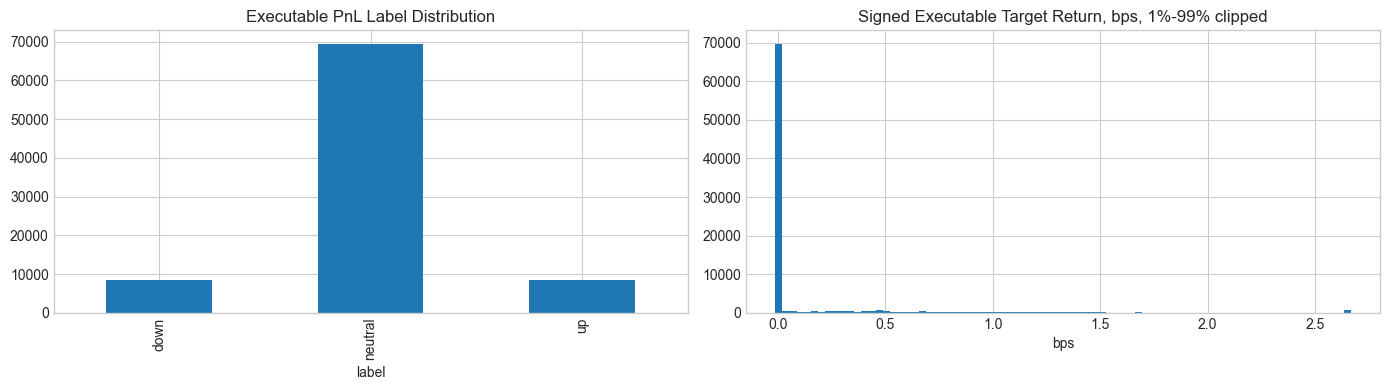

In [5]:
feature_cols = [c for c in FEATURE_COLUMNS if c in ds.columns]
target_col = 'target_exec_return' if 'target_exec_return' in ds.columns else 'target_return'
required_cols = set(feature_cols + [target_col, 'label', 'buy_pnl', 'sell_pnl', 'mid_price'])
missing = sorted(required_cols - set(ds.columns))
if missing:
    raise ValueError(f'Dataset is missing required columns: {missing}')

print('target_col:', target_col)
print('feature_count:', len(feature_cols))
print(feature_cols)

summary_cols = ['best_bid_px', 'best_ask_px', 'spread', 'label_eps', 'buy_pnl', 'sell_pnl', target_col]
summary_cols = [c for c in summary_cols if c in ds.columns]
display(ds[summary_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

target_pnl_approx = ds[target_col] * ds['mid_price']
sanity = pd.DataFrame({
    'target_exec_return_bps': ds[target_col] * 10000,
    'target_exec_pnl_approx': target_pnl_approx,
    'buy_pnl': ds['buy_pnl'],
    'sell_pnl': ds['sell_pnl'],
})
display(sanity.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

display(ds.groupby('label')[target_col].describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ds['label'].value_counts().reindex(['down', 'neutral', 'up']).dropna().plot(kind='bar', ax=ax[0], title='Executable PnL Label Distribution')
ds[target_col].clip(ds[target_col].quantile(0.01), ds[target_col].quantile(0.99)).mul(10000).hist(bins=80, ax=ax[1])
ax[1].set_title('Signed Executable Target Return, bps, 1%-99% clipped')
ax[1].set_xlabel('bps')
plt.tight_layout()


## Chronological Train/Test Split

For time-series data, avoid random shuffling. The first 80% of the day is used for training and the last 20% for evaluation.

In [6]:
clean = ds.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
if len(clean) < 1000:
    raise ValueError(f'Not enough clean rows for a stable train/test split: {len(clean)}')

split_idx = int(len(clean) * (1.0 - TEST_FRACTION))
train_df = clean.iloc[:split_idx].copy()
test_df = clean.iloc[split_idx:].copy()

X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df[target_col].to_numpy(dtype=float)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_test = test_df[target_col].to_numpy(dtype=float)

print('train:', X_train.shape, 'test:', X_test.shape)
print('train ts:', fmt_ms(int(train_df['ts'].min())), '->', fmt_ms(int(train_df['ts'].max())))
print('test ts :', fmt_ms(int(test_df['ts'].min())), '->', fmt_ms(int(test_df['ts'].max())))
display(pd.DataFrame({'train': train_df['label'].value_counts(), 'test': test_df['label'].value_counts()}).fillna(0).astype(int))


train: (69119, 20) test: (17280, 20)
train ts: 2026-04-12T00:00:00.009000+00:00 -> 2026-04-12T19:11:58.005000+00:00
test ts : 2026-04-12T19:11:59.025000+00:00 -> 2026-04-12T23:59:58.003000+00:00


,train,test
label,,
down,6341,2159
neutral,56176,13226
up,6602,1895


## Train XGBoost + LightGBM and Calibrate Return Magnitude

Both tree models learn the signed executable target. A chronological slice of the training period is held back for isotonic calibration, which maps raw model scores to better-calibrated executable returns without looking at the final test window.

This mirrors the current serving setup: the live system can load either runtime artifact and apply the stored calibrator before generating a signal.



In [7]:
clean = ds.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
if len(clean) < 1000:
    raise ValueError(f'Not enough clean rows for stable training: {len(clean)}')

split_idx = int(len(clean) * (1.0 - TEST_FRACTION))
train_df = clean.iloc[:split_idx].copy()
test_df = clean.iloc[split_idx:].copy()
if len(train_df) < 200 or len(test_df) < 50:
    raise ValueError(f'Need a larger train/test window, got train={len(train_df)} test={len(test_df)}')

X_train_df = train_df[feature_cols].copy()
X_test_df = test_df[feature_cols].copy()
y_train = train_df[target_col].to_numpy(dtype=float)
y_test = test_df[target_col].to_numpy(dtype=float)

calib_rows = max(100, int(len(X_train_df) * CALIBRATION_FRACTION))
calib_rows = min(calib_rows, max(1, len(X_train_df) - 1))
fit_rows = len(X_train_df) - calib_rows
X_fit_df = X_train_df.iloc[:fit_rows].copy()
X_calib_df = X_train_df.iloc[fit_rows:].copy()
y_fit = y_train[:fit_rows]
y_calib = y_train[fit_rows:]


def regression_report(y, pred):
    corr = float(np.corrcoef(y, pred)[0, 1]) if len(y) > 1 else 0.0
    if not np.isfinite(corr):
        corr = 0.0
    return {
        'mae': float(mean_absolute_error(y, pred)),
        'rmse': float(np.sqrt(mean_squared_error(y, pred))),
        'directional_accuracy': float(np.mean(np.sign(y) == np.sign(pred))),
        'corr': corr,
        'pred_mean': float(np.mean(pred)),
        'pred_std': float(np.std(pred)),
        'actual_mean': float(np.mean(y)),
        'actual_std': float(np.std(y)),
    }


def make_model(model_type):
    if model_type == 'xgboost':
        return XGBRegressor(
            objective='reg:squarederror',
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=20,
            reg_lambda=1.0,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    if model_type == 'lightgbm':
        return LGBMRegressor(
            objective='regression',
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            num_leaves=31,
            min_child_samples=80,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=-1,
        )
    raise ValueError(f'Unsupported model type: {model_type}')


model_runs = {}
summary_rows = []
for model_type in MODEL_TYPES:
    model = make_model(model_type)
    model.fit(X_fit_df, y_fit)

    raw_pred_train = np.asarray(model.predict(X_train_df), dtype=float)
    raw_pred_calib = np.asarray(model.predict(X_calib_df), dtype=float)
    raw_pred_test = np.asarray(model.predict(X_test_df), dtype=float)

    return_calibrator = None
    if len(X_calib_df) >= 100 and float(np.std(raw_pred_calib)) > 1e-12:
        return_calibrator = IsotonicRegression(out_of_bounds='clip')
        return_calibrator.fit(raw_pred_calib, y_calib)

    pred_train = np.asarray(return_calibrator.predict(raw_pred_train), dtype=float) if return_calibrator is not None else raw_pred_train
    pred_test = np.asarray(return_calibrator.predict(raw_pred_test), dtype=float) if return_calibrator is not None else raw_pred_test

    train_metrics = regression_report(y_train, pred_train)
    test_metrics = regression_report(y_test, pred_test)
    raw_test_metrics = regression_report(y_test, raw_pred_test)

    model_runs[model_type] = {
        'model': model,
        'return_calibrator': return_calibrator,
        'raw_pred_train': raw_pred_train,
        'raw_pred_calib': raw_pred_calib,
        'raw_pred_test': raw_pred_test,
        'pred_train': pred_train,
        'pred_test': pred_test,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'raw_test_metrics': raw_test_metrics,
    }
    summary_rows.append({
        'model': model_type,
        'model_name': MODEL_LABELS[model_type],
        **test_metrics,
        'train_rows': int(len(X_train_df)),
        'fit_rows': int(len(X_fit_df)),
        'calib_rows': int(len(X_calib_df)),
        'test_rows': int(len(X_test_df)),
    })

model_compare = pd.DataFrame(summary_rows).sort_values(['rmse', 'corr'], ascending=[True, False]).reset_index(drop=True)
display(model_compare)

print('train ts:', fmt_ms(int(train_df['ts'].min())), '->', fmt_ms(int(train_df['ts'].max())))
print('test ts :', fmt_ms(int(test_df['ts'].min())), '->', fmt_ms(int(test_df['ts'].max())))
print('fit_rows:', len(X_fit_df), 'calib_rows:', len(X_calib_df), 'test_rows:', len(X_test_df))
for model_type in MODEL_TYPES:
    run = model_runs[model_type]
    print(f"{MODEL_LABELS[model_type]} calibrator:", type(run['return_calibrator']).__name__ if run['return_calibrator'] is not None else 'none')
    print(f"{MODEL_LABELS[model_type]} test calibrated:", run['test_metrics'])
    print(f"{MODEL_LABELS[model_type]} test raw       :", run['raw_test_metrics'])



,model,model_name,mae,rmse,directional_accuracy,corr,pred_mean,pred_std,actual_mean,actual_std,train_rows,fit_rows,calib_rows,test_rows
0,lightgbm,LightGBM,0.000032,0.000067,0.234780,0.204791,0.000014,0.000015,0.000024,0.000067,69119,55296,13823,17280
1,xgboost,XGBoost,0.000031,0.000067,0.234722,0.233095,0.000012,0.000007,0.000024,0.000067,69119,55296,13823,17280


train ts: 2026-04-12T00:00:00.009000+00:00 -> 2026-04-12T19:11:58.005000+00:00
test ts : 2026-04-12T19:11:59.025000+00:00 -> 2026-04-12T23:59:58.003000+00:00
fit_rows: 55296 calib_rows: 13823 test_rows: 17280
XGBoost calibrator: IsotonicRegression
XGBoost test calibrated: {'mae': 3.1113595617184193e-05, 'rmse': 6.69650617470331e-05, 'directional_accuracy': 0.23472222222222222, 'corr': 0.23309527041719147, 'pred_mean': 1.2210668122316933e-05, 'pred_std': 7.395562437693647e-06, 'actual_mean': 2.3724592141251493e-05, 'actual_std': 6.729845743122576e-05}
XGBoost test raw       : {'mae': 3.4322095054714826e-05, 'rmse': 6.61586774769711e-05, 'directional_accuracy': 0.23472222222222222, 'corr': 0.23679154618317308, 'pred_mean': 1.7900425376690572e-05, 'pred_std': 7.694708676969294e-06, 'actual_mean': 2.3724592141251493e-05, 'actual_std': 6.729845743122576e-05}
LightGBM calibrator: IsotonicRegression
LightGBM test calibrated: {'mae': 3.1848888311202554e-05, 'rmse': 6.659169286492551e-05, 'dire

## Save Runtime-Compatible Model Artifacts

Each model is saved twice:

- a run-tagged research artifact for reproducibility
- the runtime alias that `inference-python` resolves by default

This keeps the notebook useful for research while also producing deployable artifacts for the live system.



In [8]:
MODEL_OUT_PATHS['xgboost'].parent.mkdir(parents=True, exist_ok=True)

if 'label_eps' in clean.columns and 'mid_price' in clean.columns:
    label_eps_ret = (
        pd.to_numeric(clean['label_eps'], errors='coerce')
        / pd.to_numeric(clean['mid_price'], errors='coerce')
    ).replace([np.inf, -np.inf], np.nan).dropna()
    label_eps_ret = float(label_eps_ret[label_eps_ret >= 0].median()) if not label_eps_ret.empty else EPS
else:
    label_eps_ret = EPS

artifact_registry = {}
for model_type in MODEL_TYPES:
    run = model_runs[model_type]
    artifact = {
        'model_type': f'{model_type}_regressor',
        'model_name': 'PulseXGBoostV1' if model_type == 'xgboost' else 'PulseLightGBMV1',
        'horizon_sec': HORIZON_MS // 1000,
        'feature_columns': feature_cols,
        'label_classes': sorted(clean['label'].dropna().astype(str).unique().tolist()) if 'label' in clean.columns else [],
        'label_eps': label_eps_ret,
        'prediction_target': 'signed_executable_return',
        'model': run['model'],
        'return_calibrator': run['return_calibrator'],
        'metrics': {
            **run['test_metrics'],
            'train_rows': int(len(X_train_df)),
            'fit_rows': int(len(X_fit_df)),
            'calib_rows': int(len(X_calib_df)),
            'test_rows': int(len(X_test_df)),
        },
        'run_tag': RUN_TAG,
    }
    run_path = MODEL_OUT_PATHS[model_type]
    joblib.dump(artifact, run_path)

    runtime_path = RUNTIME_MODEL_PATHS[model_type]
    if SAVE_RUNTIME_ALIASES:
        if runtime_path.resolve() != run_path.resolve():
            shutil.copy2(run_path, runtime_path)
        else:
            joblib.dump(artifact, runtime_path)

    artifact_registry[model_type] = {
        'run_tag_path': str(run_path),
        'runtime_path': str(runtime_path),
    }
    print(f"Saved {MODEL_LABELS[model_type]} artifact: {run_path}")
    if SAVE_RUNTIME_ALIASES:
        print(f"Updated runtime alias: {runtime_path}")

selected_metric_model = str(model_compare.iloc[0]['model'])
shutil.copy2(RUNTIME_MODEL_PATHS[selected_metric_model], BEST_MODEL_ARTIFACT)
print('best metric model:', selected_metric_model)
print('best runtime artifact:', BEST_MODEL_ARTIFACT)
print('artifact label_eps_return:', label_eps_ret)



Saved XGBoost artifact: /Volumes/Dev/Workspace/okx_trading_platform_sample/models/pulse_xgboost_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.joblib
Updated runtime alias: /Volumes/Dev/Workspace/okx_trading_platform_sample/models/pulse_xgboost_v1.joblib
Saved LightGBM artifact: /Volumes/Dev/Workspace/okx_trading_platform_sample/models/pulse_lightgbm_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.joblib
Updated runtime alias: /Volumes/Dev/Workspace/okx_trading_platform_sample/models/pulse_lightgbm_v1.joblib
best metric model: lightgbm
best runtime artifact: /Volumes/Dev/Workspace/okx_trading_platform_sample/models/pulse_best_model.artifact
artifact label_eps_return: 4.199642610047169e-07


## Convert Predictions to Trading Signals and Compare Models

`pred_return` is calibrated signed executable return. For strategy PnL below, `up` receives `buy_pnl` and `down` receives `sell_pnl`; no extra spread/slippage is subtracted because the target already uses executable bid/ask prices.

The comparison table lets you choose whether the deployment candidate should be driven by regression quality, realized executable PnL, or both.



In [9]:
def apply_signals(frame, pred, threshold):
    out = frame.copy()
    out['pred_return'] = np.asarray(pred, dtype=float)
    out['pred_return_bps'] = out['pred_return'] * 10000
    out['pred_signal'] = np.where(out['pred_return'] > threshold, 'up', np.where(out['pred_return'] < -threshold, 'down', 'neutral'))
    out['strategy_pnl'] = np.where(out['pred_signal'] == 'up', out['buy_pnl'], np.where(out['pred_signal'] == 'down', out['sell_pnl'], 0.0))
    out['strategy_return'] = np.where(out['mid_price'].abs() > 1e-12, out['strategy_pnl'] / out['mid_price'], 0.0)
    out['strategy_cum_pnl'] = out['strategy_pnl'].cumsum()
    out['strategy_pnl_per_notional'] = NOTIONAL_USD * out['strategy_return']
    out['strategy_cum_pnl_per_notional'] = out['strategy_pnl_per_notional'].cumsum()
    out['expected_pnl_per_notional'] = np.where(
        out['pred_signal'] == 'up',
        NOTIONAL_USD * out['pred_return'],
        np.where(out['pred_signal'] == 'down', NOTIONAL_USD * -out['pred_return'], 0.0),
    )
    return out


def trading_report(frame):
    traded = frame['pred_signal'] != 'neutral'
    realized = frame.loc[traded, 'strategy_pnl']
    realized_notional = frame.loc[traded, 'strategy_pnl_per_notional']
    cum = frame['strategy_cum_pnl_per_notional'].to_numpy(dtype=float)
    peak = np.maximum.accumulate(cum) if len(cum) else np.array([0.0])
    return {
        'rows': int(len(frame)),
        'trades': int(traded.sum()),
        'coverage': float(traded.mean()) if len(frame) else 0.0,
        'total_pnl_per_1btc': float(frame['strategy_pnl'].sum()),
        f'total_pnl_per_{NOTIONAL_USD:.0f}_usd': float(frame['strategy_pnl_per_notional'].sum()),
        'avg_pnl_per_trade_per_1btc': float(realized.mean()) if len(realized) else 0.0,
        f'avg_pnl_per_trade_per_{NOTIONAL_USD:.0f}_usd': float(realized_notional.mean()) if len(realized_notional) else 0.0,
        'win_rate': float((realized > 0).mean()) if len(realized) else 0.0,
        f'avg_expected_pnl_per_{NOTIONAL_USD:.0f}_usd': float(frame.loc[traded, 'expected_pnl_per_notional'].mean()) if traded.any() else 0.0,
        f'max_drawdown_per_{NOTIONAL_USD:.0f}_usd': float(np.max(peak - cum)) if len(cum) else 0.0,
    }


thresholds = [0.0, 0.000005, 0.00001, 0.00002, 0.00003, 0.00005, 0.0001, 0.0002, 0.0005]
threshold_rows = []
pred_frames = {}
selected_threshold_by_model = {}
selected_frame_by_model = {}

for model_type in MODEL_TYPES:
    pred_frames[model_type] = {}
    for th in thresholds:
        pf = apply_signals(test_df, model_runs[model_type]['pred_test'], th)
        pred_frames[model_type][th] = pf
        threshold_rows.append({
            'model': model_type,
            'model_name': MODEL_LABELS[model_type],
            'threshold': th,
            'threshold_bps': th * 10000,
            **trading_report(pf),
        })

threshold_report = pd.DataFrame(threshold_rows)
display(threshold_report)

pnl_col = f'total_pnl_per_{NOTIONAL_USD:.0f}_usd'
avg_pnl_col = f'avg_pnl_per_trade_per_{NOTIONAL_USD:.0f}_usd'
best_rows = []
for model_type in MODEL_TYPES:
    model_thresholds = threshold_report[threshold_report['model'] == model_type].copy()
    eligible = model_thresholds[model_thresholds['trades'] >= max(25, int(0.01 * len(test_df)))]
    if eligible.empty:
        eligible = model_thresholds[model_thresholds['trades'] > 0]
    if eligible.empty:
        chosen_threshold = 0.0
    else:
        chosen_threshold = float(eligible.sort_values([pnl_col, avg_pnl_col], ascending=False).iloc[0]['threshold'])
    selected_threshold_by_model[model_type] = chosen_threshold
    selected_frame_by_model[model_type] = pred_frames[model_type][chosen_threshold]
    best_rows.append({
        'model': model_type,
        'model_name': MODEL_LABELS[model_type],
        'selected_threshold': chosen_threshold,
        'selected_threshold_bps': chosen_threshold * 10000,
        **model_runs[model_type]['test_metrics'],
        **trading_report(selected_frame_by_model[model_type]),
    })

model_selection = pd.DataFrame(best_rows).sort_values([pnl_col, 'corr'], ascending=[False, False]).reset_index(drop=True)
display(model_selection)



,model,model_name,threshold,threshold_bps,rows,trades,coverage,total_pnl_per_1btc,total_pnl_per_5000_usd,avg_pnl_per_trade_per_1btc,avg_pnl_per_trade_per_5000_usd,win_rate,avg_expected_pnl_per_5000_usd,max_drawdown_per_5000_usd
0,xgboost,XGBoost,0.000000,0.00,17280,17280,1.000000,-2389.2,-168.110543,-0.138264,-0.009729,0.109780,0.061053,178.270288
1,xgboost,XGBoost,0.000005,0.05,17280,17280,1.000000,-2389.2,-168.110543,-0.138264,-0.009729,0.109780,0.061053,178.270288
2,xgboost,XGBoost,0.000010,0.10,17280,3671,0.212442,-1356.7,-95.458594,-0.369572,-0.026003,0.204576,0.116608,109.209893
3,xgboost,XGBoost,0.000020,0.20,17280,1421,0.082234,-874.7,-61.533833,-0.615552,-0.043303,0.248417,0.158896,70.068232
4,xgboost,XGBoost,0.000030,0.30,17280,691,0.039988,-295.6,-20.757780,-0.427786,-0.030040,0.292330,0.213320,33.396030
5,xgboost,XGBoost,0.000050,0.50,17280,79,0.004572,-186.5,-13.138350,-2.360759,-0.166308,0.291139,0.302985,19.414398
6,xgboost,XGBoost,0.000100,1.00,17280,0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,xgboost,XGBoost,0.000200,2.00,17280,0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,xgboost,XGBoost,0.000500,5.00,17280,0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,lightgbm,LightGBM,0.000000,0.00,17280,17280,1.000000,-2389.2,-168.110543,-0.138264,-0.009729,0.109780,0.070287,178.270288


,model,model_name,selected_threshold,selected_threshold_bps,mae,rmse,directional_accuracy,corr,pred_mean,pred_std,actual_mean,actual_std,rows,trades,coverage,total_pnl_per_1btc,total_pnl_per_5000_usd,avg_pnl_per_trade_per_1btc,avg_pnl_per_trade_per_5000_usd,win_rate,avg_expected_pnl_per_5000_usd,max_drawdown_per_5000_usd
0,xgboost,XGBoost,0.00003,0.3,0.000031,0.000067,0.234722,0.233095,0.000012,0.000007,0.000024,0.000067,17280,691,0.039988,-295.6,-20.75778,-0.427786,-0.030040,0.292330,0.213320,33.396030
1,lightgbm,LightGBM,0.00005,0.5,0.000032,0.000067,0.234780,0.204791,0.000014,0.000015,0.000024,0.000067,17280,248,0.014352,-604.7,-42.53309,-2.438306,-0.171504,0.237903,0.567748,47.502522


## Visualize Predictions, PnL, and Runtime Recommendation

The charts below compare both tree models on the held-out window. The first comparison is about forecast shape, the second is about realized executable PnL after thresholding, and the third highlights the selected runtime recommendation.

If all models remain negative on held-out executable PnL, the notebook switches to a `shadow_only` recommendation instead of claiming the model is ready for auto-trading.



selected runtime model: lightgbm LightGBM
deployment_mode: shadow_only
deployment_note: No model produced positive held-out executable PnL; use the best regression model for shadow mode first.
selected_threshold: 5e-05 (0.500 bps)


,model,model_name,selected_threshold,selected_threshold_bps,mae,rmse,directional_accuracy,corr,pred_mean,pred_std,actual_mean,actual_std,rows,trades,coverage,total_pnl_per_1btc,total_pnl_per_5000_usd,avg_pnl_per_trade_per_1btc,avg_pnl_per_trade_per_5000_usd,win_rate,avg_expected_pnl_per_5000_usd,max_drawdown_per_5000_usd
0,xgboost,XGBoost,0.00003,0.3,0.000031,0.000067,0.234722,0.233095,0.000012,0.000007,0.000024,0.000067,17280,691,0.039988,-295.6,-20.75778,-0.427786,-0.030040,0.292330,0.213320,33.396030
1,lightgbm,LightGBM,0.00005,0.5,0.000032,0.000067,0.234780,0.204791,0.000014,0.000015,0.000024,0.000067,17280,248,0.014352,-604.7,-42.53309,-2.438306,-0.171504,0.237903,0.567748,47.502522


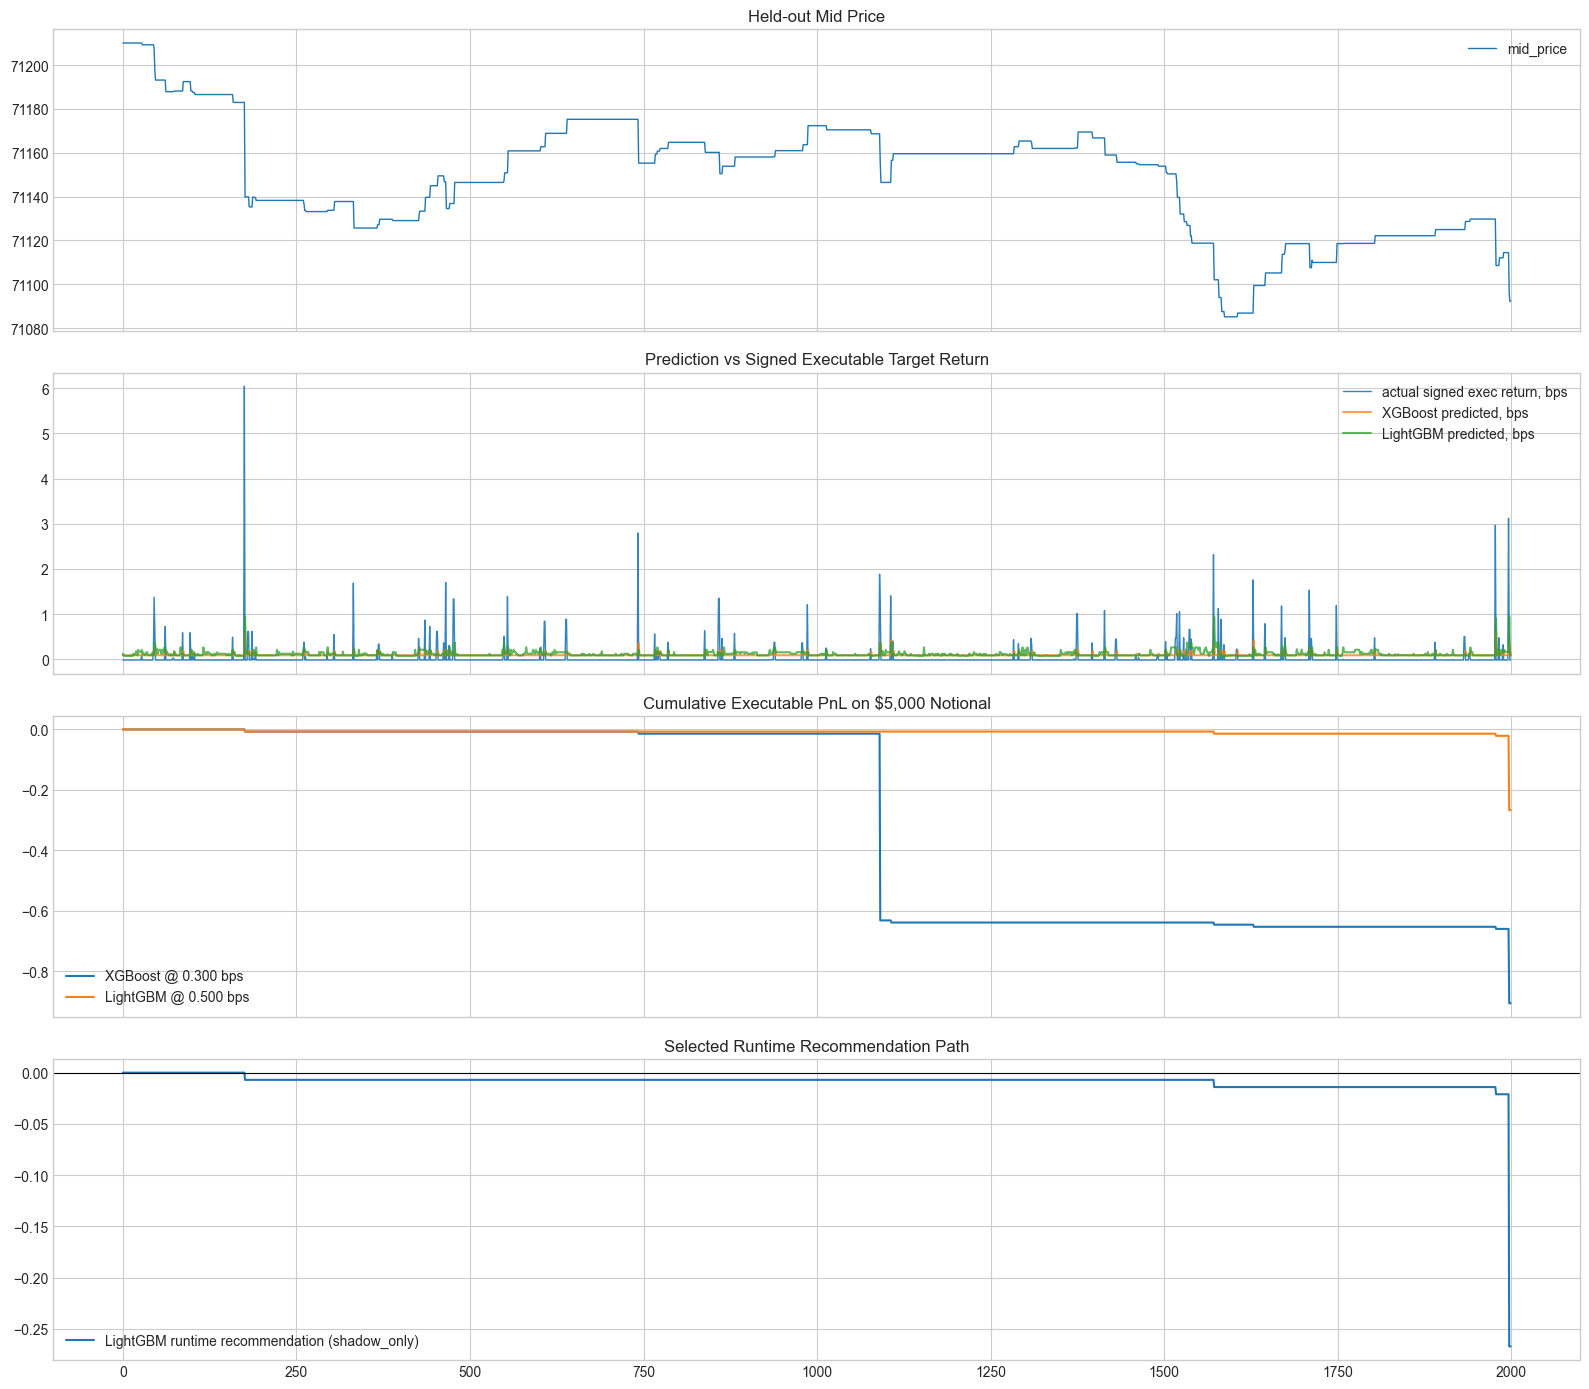

In [10]:
positive_candidates = model_selection[model_selection[pnl_col] > 0].copy()
if not positive_candidates.empty:
    selected_model_type = str(positive_candidates.sort_values([pnl_col, 'corr'], ascending=[False, False]).iloc[0]['model'])
    deployment_mode = 'auto_trading_candidate'
    deployment_note = 'At least one model produced positive held-out executable PnL.'
else:
    selected_model_type = str(model_compare.iloc[0]['model'])
    deployment_mode = 'shadow_only'
    deployment_note = 'No model produced positive held-out executable PnL; use the best regression model for shadow mode first.'

selected_model_label = MODEL_LABELS[selected_model_type]
selected_threshold = float(selected_threshold_by_model[selected_model_type])
pred_df = selected_frame_by_model[selected_model_type].copy()

print('selected runtime model:', selected_model_type, selected_model_label)
print('deployment_mode:', deployment_mode)
print('deployment_note:', deployment_note)
print('selected_threshold:', selected_threshold, f'({selected_threshold * 10000:.3f} bps)')
display(model_selection)

eval_window = min(len(test_df), 2000)
plot_df = test_df.iloc[:eval_window].reset_index(drop=True)

fig, ax = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
ax[0].plot(plot_df['mid_price'].to_numpy(), label='mid_price', linewidth=1.0)
ax[0].set_title('Held-out Mid Price')
ax[0].legend()

ax[1].plot((plot_df[target_col].to_numpy() * 10000), label='actual signed exec return, bps', linewidth=1.0, alpha=0.9)
for model_type in MODEL_TYPES:
    ax[1].plot(model_runs[model_type]['pred_test'][:eval_window] * 10000, label=f"{MODEL_LABELS[model_type]} predicted, bps", alpha=0.75)
ax[1].set_title('Prediction vs Signed Executable Target Return')
ax[1].legend()

for model_type in MODEL_TYPES:
    ax[2].plot(
        selected_frame_by_model[model_type]['strategy_cum_pnl_per_notional'].iloc[:eval_window].to_numpy(),
        label=f"{MODEL_LABELS[model_type]} @ {selected_threshold_by_model[model_type] * 10000:.3f} bps",
    )
ax[2].set_title(f'Cumulative Executable PnL on ${NOTIONAL_USD:,.0f} Notional')
ax[2].legend()

ax[3].plot(pred_df['strategy_cum_pnl_per_notional'].iloc[:eval_window].to_numpy(), label=f'{selected_model_label} runtime recommendation ({deployment_mode})')
ax[3].axhline(0.0, color='black', linewidth=0.8)
ax[3].set_title('Selected Runtime Recommendation Path')
ax[3].legend()

plt.tight_layout()



## Calibration Check and Live Inference Smoke Test

This section checks two things:

1. whether calibrated prediction magnitude tracks signed executable return
2. whether the saved runtime artifact can be loaded through `PredictionService.LoadedModel` using the same feature shape the live gRPC path sends



XGBoost


,count,mean,std,min,25%,50%,75%,max
bps,,,,,,,,
actual,5000.0,0.042084,0.271619,-0.014093,-0.014071,-0.014064,-0.014053,6.040772
raw_predicted,5000.0,0.155182,0.036041,0.146960,0.146960,0.146960,0.146960,0.713235
calibrated_predicted,5000.0,0.099720,0.033636,0.092135,0.092135,0.092135,0.092135,0.605971


LightGBM


,count,mean,std,min,25%,50%,75%,max
bps,,,,,,,,
actual,5000.0,0.042084,0.271619,-0.014093,-0.014071,-0.014064,-0.014053,6.040772
raw_predicted,5000.0,0.239860,0.128798,0.065677,0.143647,0.223278,0.290151,1.768396
calibrated_predicted,5000.0,0.103685,0.052995,0.077080,0.077080,0.087766,0.092632,0.976885


/opt/homebrew/Caskroom/miniconda/base/envs/genai/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,runtime_path,mode,predicted_return,predicted_return_bps
0,xgboost,/Volumes/Dev/Workspace/okx_trading_platform_sa...,xgboost_regressor,0.000009,0.092135
1,lightgbm,/Volumes/Dev/Workspace/okx_trading_platform_sa...,lightgbm_regressor,0.000008,0.077080


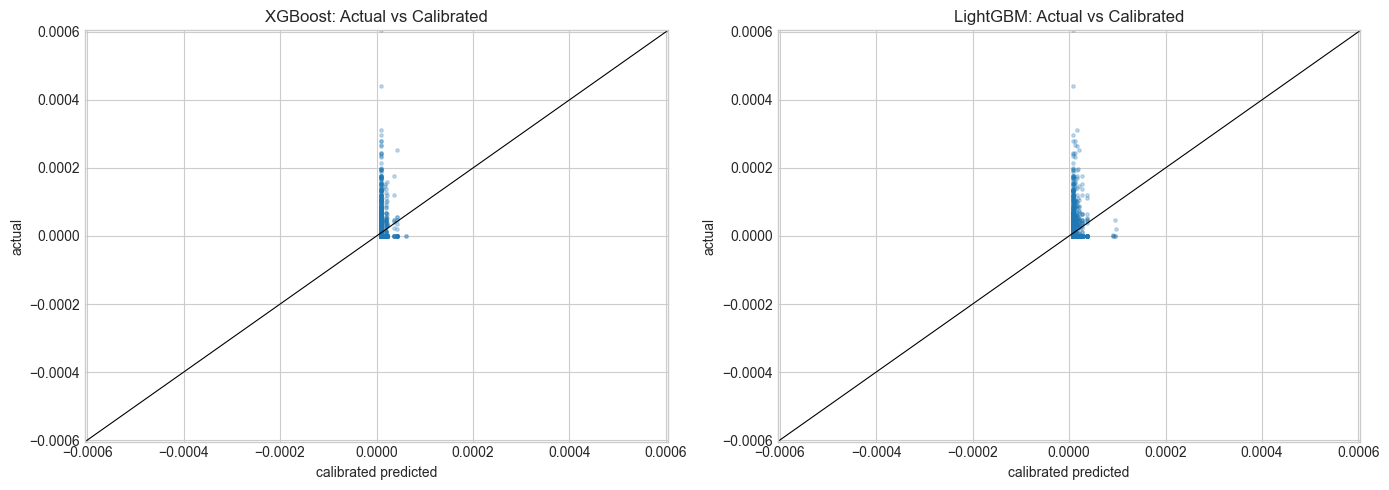

In [11]:
sample_n = min(len(test_df), 5000)
fig, axes = plt.subplots(1, len(MODEL_TYPES), figsize=(7 * len(MODEL_TYPES), 5))
if len(MODEL_TYPES) == 1:
    axes = [axes]

calibration_tables = {}
for ax, model_type in zip(axes, MODEL_TYPES):
    sample = pd.DataFrame({
        'actual': y_test[:sample_n],
        'raw_predicted': model_runs[model_type]['raw_pred_test'][:sample_n],
        'calibrated_predicted': model_runs[model_type]['pred_test'][:sample_n],
    })
    sample['residual'] = sample['actual'] - sample['calibrated_predicted']
    calibration_tables[model_type] = sample
    lim = max(abs(sample[['actual', 'calibrated_predicted']]).max().max(), 1e-6)
    ax.scatter(sample['calibrated_predicted'], sample['actual'], s=6, alpha=0.25)
    ax.plot([-lim, lim], [-lim, lim], color='black', linewidth=0.8)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(f'{MODEL_LABELS[model_type]}: Actual vs Calibrated')
    ax.set_xlabel('calibrated predicted')
    ax.set_ylabel('actual')

plt.tight_layout()

for model_type in MODEL_TYPES:
    print(MODEL_LABELS[model_type])
    display(
        calibration_tables[model_type][['actual', 'raw_predicted', 'calibrated_predicted']]
        .mul(10000)
        .describe()
        .T
        .rename_axis('bps')
    )

smoke_test = {'enabled': bool(RUN_LIVE_SMOKE_TEST), 'results': []}
if RUN_LIVE_SMOKE_TEST:
    from ml_pipeline.serving.app import PredictionService

    smoke_rows = clean.dropna(subset=feature_cols + ['price', 'best_bid_px', 'best_ask_px', 'best_bid_sz', 'best_ask_sz']).tail(8).copy()
    smoke_points = []
    for _, row in smoke_rows.iterrows():
        point = {
            'ts': int(row['ts']),
            'price': float(row['price']),
            'bid_px': float(row['best_bid_px']),
            'ask_px': float(row['best_ask_px']),
            'bid_sz': float(row['best_bid_sz']),
            'ask_sz': float(row['best_ask_sz']),
        }
        for col in feature_cols:
            point[col] = float(row[col])
        smoke_points.append(point)
    smoke_prices = smoke_rows['price'].to_numpy(dtype=float)

    for model_type in MODEL_TYPES:
        runtime_path = RUNTIME_MODEL_PATHS[model_type]
        loaded = PredictionService.LoadedModel(runtime_path)
        pred = float(loaded.predict_return(smoke_prices, smoke_points))
        smoke_test['results'].append({
            'model': model_type,
            'runtime_path': str(runtime_path),
            'mode': loaded.mode,
            'predicted_return': pred,
            'predicted_return_bps': pred * 10000,
        })

display(pd.DataFrame(smoke_test['results']))



## Feature Importance Comparison

These importances come from the two deployable tree models. Features that rank well in both models are usually the safest candidates to preserve tightly between offline training and the live `backend-cpp` feature builder.



,xgboost,lightgbm,xgboost_rank,lightgbm_rank,mean_importance
delta_mid_price,0.238477,1597,2.0,1.0,798.619239
delta_imbalance_l5,0.000000,798,5.0,2.0,399.000000
mid_price,0.286150,788,1.0,3.0,394.143075
weighted_ask_depth,0.000000,712,5.0,4.0,356.000000
rel_spread,0.237386,572,4.0,5.0,286.118693
bid_vol_l5,0.000000,560,5.0,6.0,280.000000
weighted_bid_depth,0.000000,540,5.0,7.0,270.000000
ask_vol_l5,0.000000,468,5.0,8.0,234.000000
imbalance_l1,0.000000,466,5.0,9.0,233.000000
imbalance,0.000000,440,5.0,10.0,220.000000


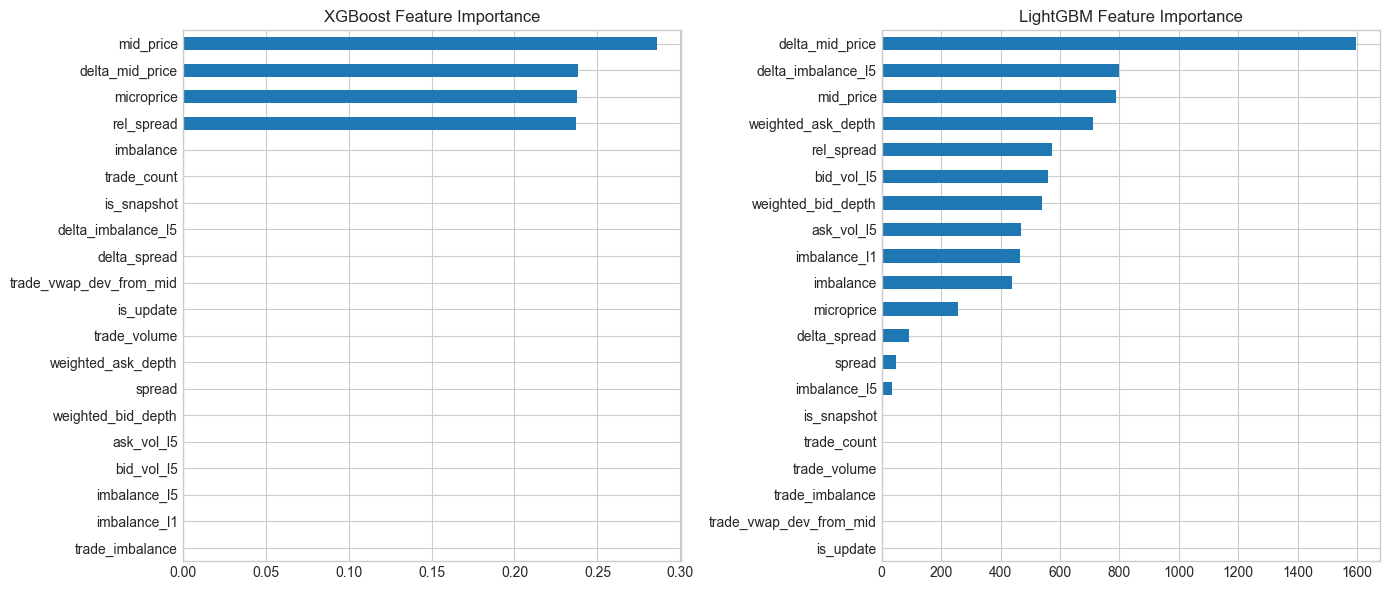

In [12]:
importance_table = pd.DataFrame({
    model_type: pd.Series(model_runs[model_type]['model'].feature_importances_, index=feature_cols)
    for model_type in MODEL_TYPES
}).fillna(0.0)
importance_table['xgboost_rank'] = importance_table['xgboost'].rank(ascending=False, method='dense') if 'xgboost' in importance_table.columns else np.nan
importance_table['lightgbm_rank'] = importance_table['lightgbm'].rank(ascending=False, method='dense') if 'lightgbm' in importance_table.columns else np.nan
importance_table['mean_importance'] = importance_table[[c for c in MODEL_TYPES if c in importance_table.columns]].mean(axis=1)
importance_table = importance_table.sort_values('mean_importance', ascending=False)

display(importance_table.head(30))

fig, axes = plt.subplots(1, len(MODEL_TYPES), figsize=(7 * len(MODEL_TYPES), 6))
if len(MODEL_TYPES) == 1:
    axes = [axes]
for ax, model_type in zip(axes, MODEL_TYPES):
    importance = pd.Series(model_runs[model_type]['model'].feature_importances_, index=feature_cols).sort_values(ascending=False)
    importance.head(20).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'{MODEL_LABELS[model_type]} Feature Importance')
plt.tight_layout()



## Save Predictions, Comparison Tables, and Evaluation JSON

The saved JSON now includes:

- dual-model regression metrics
- thresholded trading comparisons
- the selected runtime recommendation and deployment mode
- runtime artifact paths
- a live-path smoke test summary
- the current system architecture stages for downstream reporting



In [13]:
PRED_OUT.parent.mkdir(parents=True, exist_ok=True)
MODEL_COMPARE_CSV.parent.mkdir(parents=True, exist_ok=True)

pred_df.to_csv(PRED_OUT, index=False)
model_compare.to_csv(MODEL_COMPARE_CSV, index=False)

metrics = {
    'run_tag': RUN_TAG,
    'dataset_csv': str(DATASET_CSV),
    'prediction_target': 'signed_executable_return',
    'notional_usd': NOTIONAL_USD,
    'requested_books_start_day': REQUESTED_BOOKS_START_DAY,
    'requested_books_end_day': REQUESTED_BOOKS_END_DAY,
    'requested_trades_start_day': REQUESTED_TRADES_START_DAY,
    'requested_trades_end_day': REQUESTED_TRADES_END_DAY,
    'effective_books_start_day': BOOKS_START_DAY,
    'effective_books_end_day': BOOKS_END_DAY,
    'effective_trades_start_day': TRADES_START_DAY,
    'effective_trades_end_day': TRADES_END_DAY,
    'feature_count': len(feature_cols),
    'features': feature_cols,
    'model_artifacts': artifact_registry,
    'model_compare_csv': str(MODEL_COMPARE_CSV),
    'best_model_artifact': str(BEST_MODEL_ARTIFACT),
    'regression_models': {
        model_type: {
            'model_name': MODEL_LABELS[model_type],
            'test_calibrated': model_runs[model_type]['test_metrics'],
            'test_raw': model_runs[model_type]['raw_test_metrics'],
            'selected_threshold': selected_threshold_by_model[model_type],
            'selected_trading': trading_report(selected_frame_by_model[model_type]),
        }
        for model_type in MODEL_TYPES
    },
    'runtime_recommendation': {
        'model': selected_model_type,
        'model_name': selected_model_label,
        'runtime_model_path': str(RUNTIME_MODEL_PATHS[selected_model_type]),
        'deployment_mode': deployment_mode,
        'deployment_note': deployment_note,
        'selected_threshold': selected_threshold,
        'selected_threshold_bps': selected_threshold * 10000,
        'trading': trading_report(pred_df),
    },
    'selected_deployment_model': {
        'model': selected_model_type,
        'model_name': selected_model_label,
        'runtime_model_path': str(RUNTIME_MODEL_PATHS[selected_model_type]),
        'deployment_mode': deployment_mode,
        'deployment_note': deployment_note,
        'selected_threshold': selected_threshold,
        'selected_threshold_bps': selected_threshold * 10000,
        'trading': trading_report(pred_df),
    },
    'threshold_report': threshold_report.to_dict(orient='records'),
    'model_selection_table': model_selection.to_dict(orient='records'),
    'live_smoke_test': smoke_test,
    'architecture': {
        'source': 'OKX books/trades websocket',
        'backend': 'backend-cpp reconstructs snapshot/update books and rolling trade features',
        'inference': 'inference-python loads pulse_xgboost_v1.joblib or pulse_lightgbm_v1.joblib',
        'gateway': 'web-gateway proxies runtime predictions',
        'frontend': 'frontend displays predicted return and auto-trading signals',
    },
}
METRICS_JSON.parent.mkdir(parents=True, exist_ok=True)
METRICS_JSON.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

print(f'Saved predictions: {PRED_OUT}')
print(f'Saved model compare: {MODEL_COMPARE_CSV}')
print(f'Saved metrics: {METRICS_JSON}')
display(pred_df[['ts', 'mid_price', target_col, 'pred_return', 'pred_return_bps', 'pred_signal', 'expected_pnl_per_notional', 'buy_pnl', 'sell_pnl', 'strategy_pnl', 'strategy_pnl_per_notional', 'strategy_cum_pnl_per_notional']].head(20))



Saved predictions: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/notebook_predictions_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.csv
Saved model compare: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/notebook_model_compare_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.csv
Saved metrics: /Volumes/Dev/Workspace/okx_trading_platform_sample/data/notebook_model_eval_btcusdt_books_2026-04-12_2026-04-12_trades_2026-04-12_2026-04-12_h1000ms.json


,ts,mid_price,target_exec_return,pred_return,pred_return_bps,pred_signal,expected_pnl_per_notional,buy_pnl,sell_pnl,strategy_pnl,strategy_pnl_per_notional,strategy_cum_pnl_per_notional
69119,1776021119025,71210.05,-0.000001,0.000012,0.124964,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69120,1776021120005,71210.05,-0.000001,0.000009,0.087766,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69121,1776021121015,71210.05,-0.000001,0.000009,0.087766,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69122,1776021122005,71210.05,-0.000001,0.000008,0.077080,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69123,1776021123005,71210.05,-0.000001,0.000008,0.077080,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69124,1776021124005,71210.05,-0.000001,0.000008,0.077080,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69125,1776021125005,71210.05,-0.000001,0.000008,0.077080,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69126,1776021126015,71210.05,-0.000001,0.000008,0.077080,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69127,1776021127005,71210.05,-0.000001,0.000008,0.077080,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
69128,1776021128005,71210.05,-0.000001,0.000008,0.077080,neutral,0.0,-0.1,-0.1,0.0,0.0,0.0
